# Class 2D Nodule Sparse Code Clustering & Visualization (K-Means)

This notebook extracts **strictly Class 2D Nodule sparse codes** (`labels == 2`), excluding Normal (`0`) and 2C (`1`) patches. It performs **K-Means Clustering** to discover sub-patterns within 2D nodules and visualizes them using 2D/3D PCA projections, cluster distributions, and the Elbow Method.

In [1]:
# Ensure required dependencies are installed
%pip install --break-system-packages -q scikit-learn seaborn matplotlib pandas numpy

Note: you may need to restart the kernel to use updated packages.


## 1. Import Required Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import Normalizer

try:
    import seaborn as sns
except ImportError:
    sns = None

# Configure plotting appearance
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True

## 2. Load Sparse Codes & Filter ONLY Class 2D Nodules (`labels == 2`)

In [3]:
file_path = '/Users/pasanthilakshana/Desktop/Research/folder/sparse_codes/train_sparse_codes_lcksvd2.npz'

print(f"Loading dataset from: {file_path}")
data = np.load(file_path)

Gamma = data['Gamma']     # Matrix shape: (10368, 93985)
labels = data['labels']   # Label array: 0 = Normal, 1 = 2c, 2 = 2d

print(f"Full Gamma Matrix Shape: {Gamma.shape}")
print(f"Full Labels Array Shape: {labels.shape}")

# Filter STRICTLY for Class 2D Nodules (labels == 2)
mask_2d = (labels == 2)
X_2d_raw = Gamma[:, mask_2d].T  # Transpose to (n_samples, n_features) -> (13422, 10368)

# L2 Normalization for high-dimensional sparse representations
normalizer = Normalizer(norm='l2')
X_2d = normalizer.fit_transform(X_2d_raw)

print("\n--- Extracted Class 2D Nodule Sparse Codes ---")
print(f"Class 2D Sparse Codes Shape: {X_2d.shape}")
print(f"Total 2D Nodule Patches: {len(X_2d)}")

Loading dataset from: /Users/pasanthilakshana/Desktop/Research/folder/sparse_codes/train_sparse_codes_lcksvd2.npz
Full Gamma Matrix Shape: (10368, 93985)
Full Labels Array Shape: (93985,)

--- Extracted Class 2D Nodule Sparse Codes ---
Class 2D Sparse Codes Shape: (13422, 10368)
Total 2D Nodule Patches: 13422


## 3. Perform K-Means Clustering on Class 2D Nodules

In [4]:
# Set number of clusters to analyze sub-types within 2D nodules (e.g., K=3)
n_clusters = 4

print(f"Fitting K-Means on Class 2D Nodules with K={n_clusters}...")
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_2d)

print(f"\nClustering Complete! Inertia: {kmeans.inertia_:.2f}")

unique_clusters, counts = np.unique(cluster_labels, return_counts=True)
for c, cnt in zip(unique_clusters, counts):
    print(f"  Cluster {c}: {cnt} samples ({cnt / len(cluster_labels) * 100:.2f}%)")

Fitting K-Means on Class 2D Nodules with K=4...

Clustering Complete! Inertia: 11750.06
  Cluster 0: 677 samples (5.04%)
  Cluster 1: 11263 samples (83.91%)
  Cluster 2: 605 samples (4.51%)
  Cluster 3: 877 samples (6.53%)


## 4. Dimensionality Reduction (PCA)

In [5]:
print("Computing 2D & 3D PCA projections for Class 2D nodules...")
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_2d)
centers_pca_2d = pca_2d.transform(kmeans.cluster_centers_)

pca_3d = PCA(n_components=3, random_state=42)
X_pca_3d = pca_3d.fit_transform(X_2d)
centers_pca_3d = pca_3d.transform(kmeans.cluster_centers_)

print(f"2D PCA Explained Variance: {pca_2d.explained_variance_ratio_} (Total: {np.sum(pca_2d.explained_variance_ratio_)*100:.2f}%)")

Computing 2D & 3D PCA projections for Class 2D nodules...
2D PCA Explained Variance: [0.04464026 0.04263011] (Total: 8.73%)


## 5. Visualizations

### 5.1 2D PCA Cluster Projection & Distribution

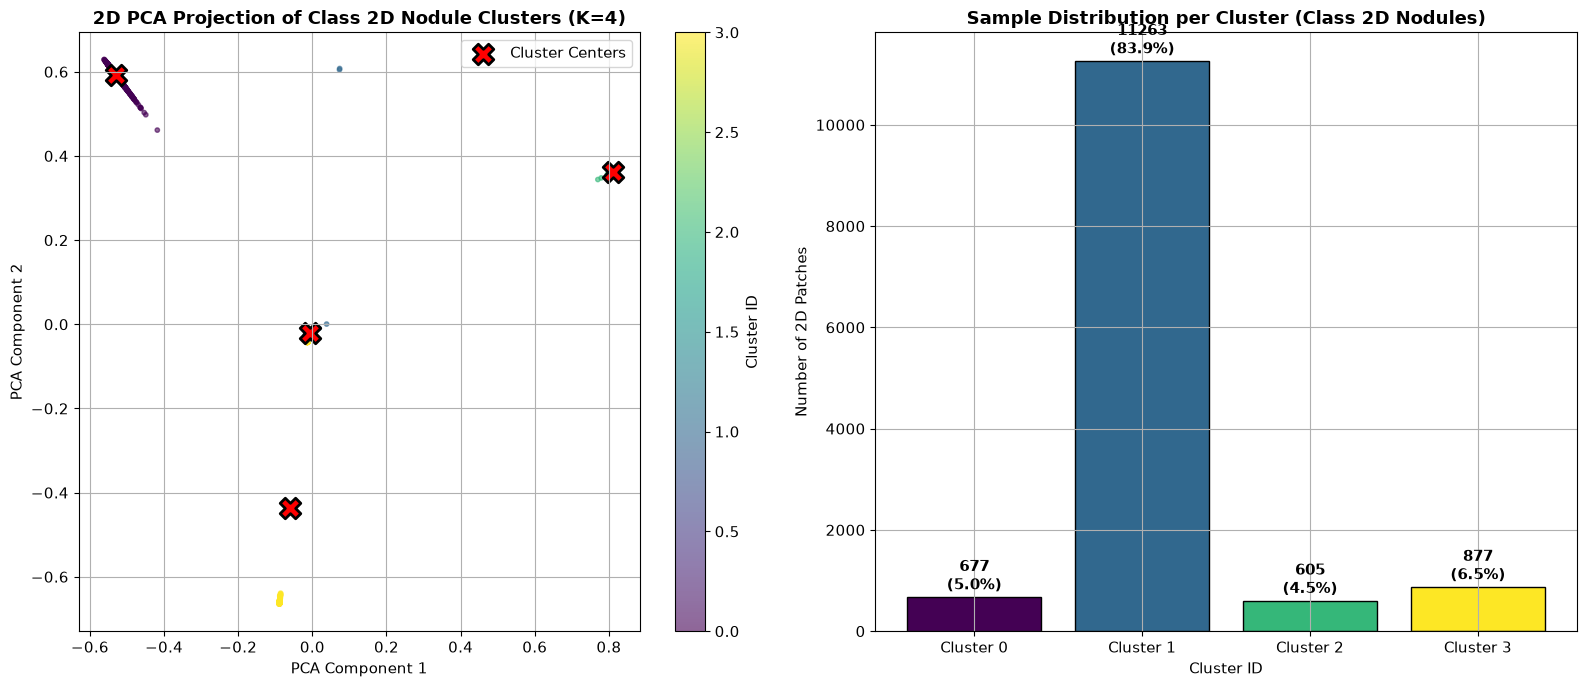

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# 2D Scatter Plot
sc1 = axes[0].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=cluster_labels, cmap='viridis', alpha=0.6, s=10)
axes[0].scatter(centers_pca_2d[:, 0], centers_pca_2d[:, 1], c='red', marker='X', s=220, linewidths=2, edgecolor='black', label='Cluster Centers')
axes[0].set_title(f'2D PCA Projection of Class 2D Nodule Clusters (K={n_clusters})', fontsize=13, fontweight='bold')
axes[0].set_xlabel('PCA Component 1')
axes[0].set_ylabel('PCA Component 2')
axes[0].legend()
plt.colorbar(sc1, ax=axes[0], label='Cluster ID')

# Cluster Distribution Bar Plot
cluster_counts = pd.Series(cluster_labels).value_counts().sort_index()
colors = plt.cm.viridis(np.linspace(0, 1, n_clusters))
bars = axes[1].bar([f'Cluster {i}' for i in cluster_counts.index], cluster_counts.values, color=colors, edgecolor='black')
axes[1].set_title('Sample Distribution per Cluster (Class 2D Nodules)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Cluster ID')
axes[1].set_ylabel('Number of 2D Patches')
for bar, v in zip(bars, cluster_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 150, f'{v}\n({v/len(cluster_labels)*100:.1f}%)', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### 5.2 3D PCA Scatter Plot of Class 2D Nodule Clusters

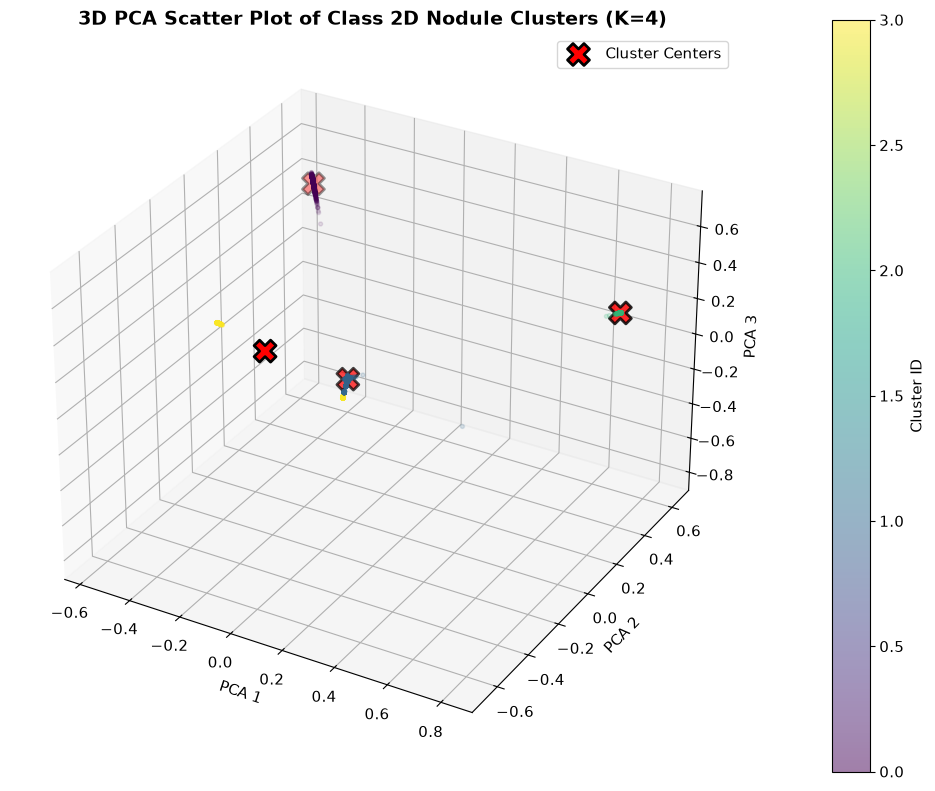

In [7]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2], c=cluster_labels, cmap='viridis', alpha=0.5, s=8)
ax.scatter(centers_pca_3d[:, 0], centers_pca_3d[:, 1], centers_pca_3d[:, 2], c='red', marker='X', s=250, linewidths=2, edgecolor='black', label='Cluster Centers')

ax.set_title(f'3D PCA Scatter Plot of Class 2D Nodule Clusters (K={n_clusters})', fontsize=14, fontweight='bold')
ax.set_xlabel('PCA 1')
ax.set_ylabel('PCA 2')
ax.set_zlabel('PCA 3')
ax.legend()
plt.colorbar(sc, ax=ax, label='Cluster ID', pad=0.1)
plt.tight_layout()
plt.show()

### 5.3 Elbow Method Curve for Class 2D Nodules

Calculating Inertia for K=1 to 7 on Class 2D nodules...


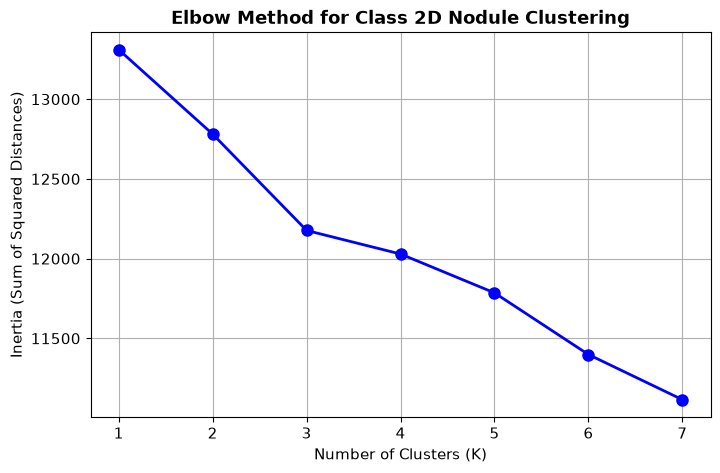

In [8]:
k_range = range(1, 8)
inertias = []

print("Calculating Inertia for K=1 to 7 on Class 2D nodules...")
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=5)
    km.fit(X_2d)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.title('Elbow Method for Class 2D Nodule Clustering', fontsize=13, fontweight='bold')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Sum of Squared Distances)')
plt.xticks(k_range)
plt.grid(True)
plt.show()

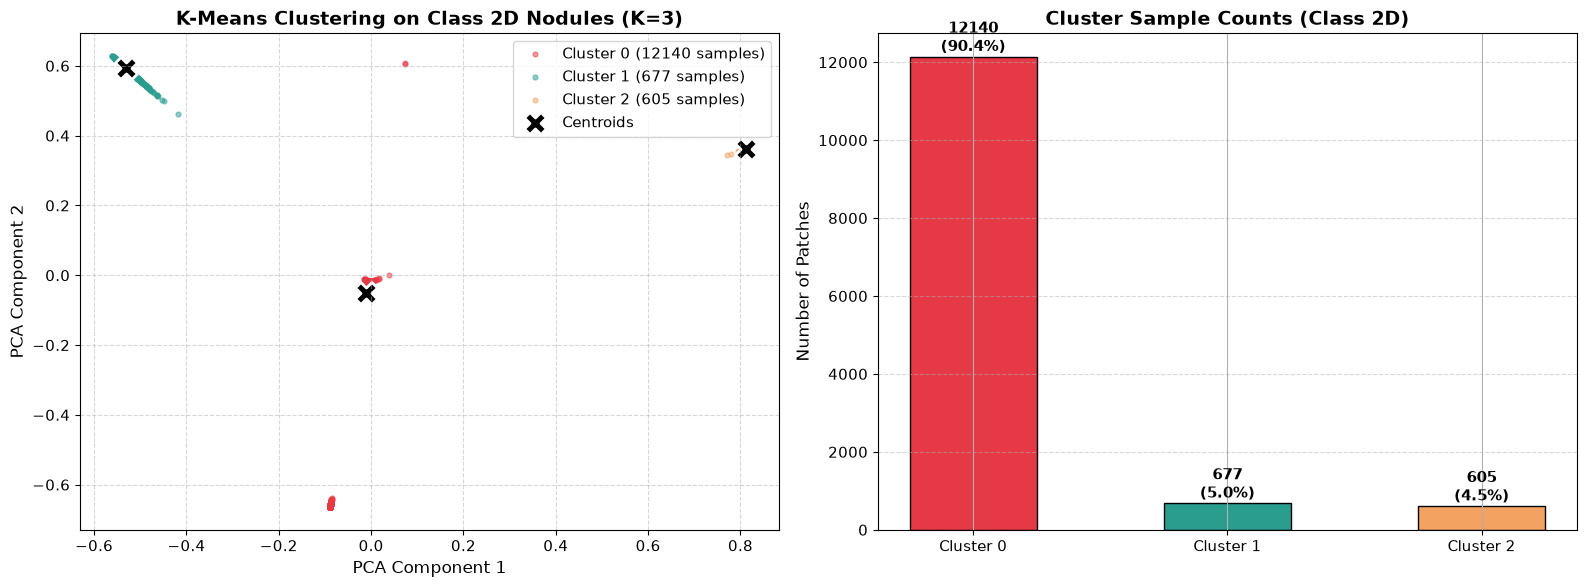

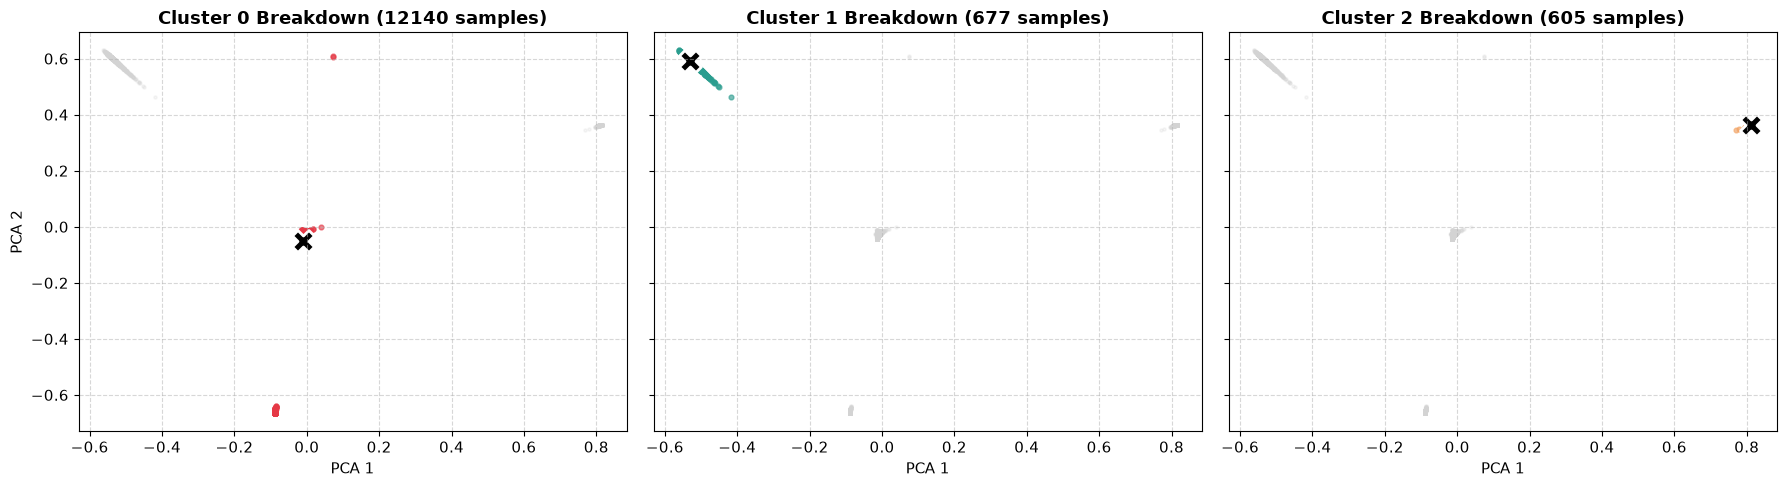

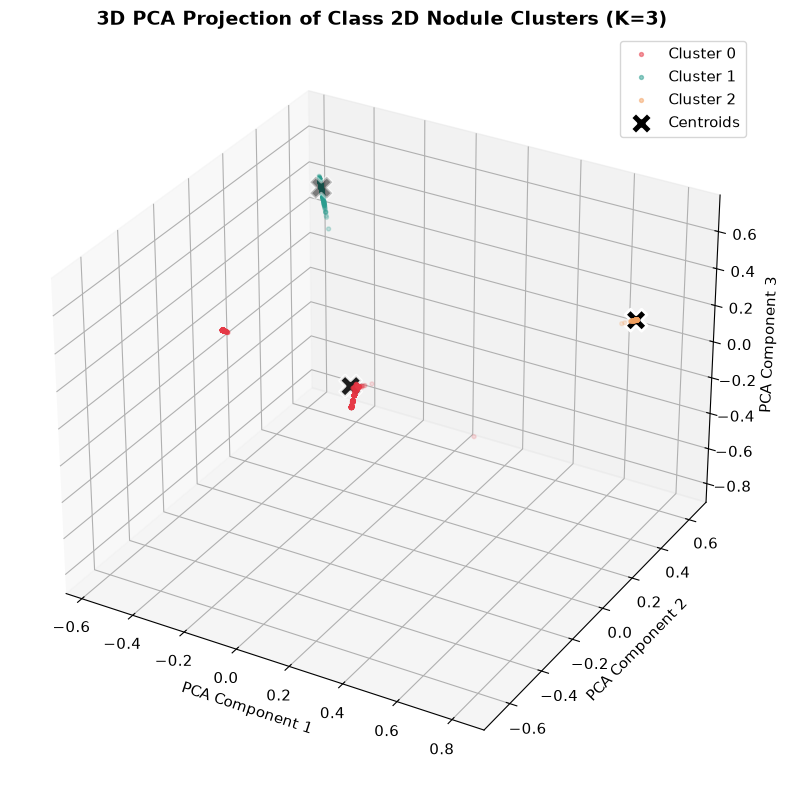

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import Normalizer

# 1. Load Dataset & Filter ONLY Class 2D Nodules (labels == 2)
file_path = '/Users/pasanthilakshana/Desktop/Research/folder/sparse_codes/train_sparse_codes_lcksvd2.npz'
data = np.load(file_path)

Gamma = data['Gamma']     # Shape: (10368, 93985)
labels = data['labels']   # Labels: 0 = Normal, 1 = 2c, 2 = 2d

mask_2d = (labels == 2)
X_2d_raw = Gamma[:, mask_2d].T  # Shape: (13422, 10368)

# 2. L2 Normalization
normalizer = Normalizer(norm='l2')
X_2d = normalizer.fit_transform(X_2d_raw)

# 3. K-Means Clustering with K=3
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_2d)

# 4. PCA Dimensionality Reduction
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_2d)
centers_pca_2d = pca_2d.transform(kmeans.cluster_centers_)

pca_3d = PCA(n_components=3, random_state=42)
X_pca_3d = pca_3d.fit_transform(X_2d)
centers_pca_3d = pca_3d.transform(kmeans.cluster_centers_)

# Color Palette for 3 Clusters
colors = ['#E63946', '#2A9D8F', '#F4A261']

# ---------------------------------------------------------
# VISUALIZATION 1: Combined 2D PCA & Cluster Size Distribution
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for c in range(n_clusters):
    mask = (cluster_labels == c)
    axes[0].scatter(
        X_pca_2d[mask, 0], X_pca_2d[mask, 1], 
        c=colors[c], label=f'Cluster {c} ({np.sum(mask)} samples)', 
        alpha=0.5, s=12
    )

# Plot Centroids
axes[0].scatter(
    centers_pca_2d[:, 0], centers_pca_2d[:, 1], 
    c='black', marker='X', s=250, linewidths=2, edgecolor='white', label='Centroids'
)
axes[0].set_title('K-Means Clustering on Class 2D Nodules (K=3)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('PCA Component 1', fontsize=12)
axes[0].set_ylabel('PCA Component 2', fontsize=12)
axes[0].legend(loc='upper right', frameon=True)
axes[0].grid(True, linestyle='--', alpha=0.5)

# Cluster Counts Bar Plot
cluster_counts = pd.Series(cluster_labels).value_counts().sort_index()
bars = axes[1].bar([f'Cluster {i}' for i in cluster_counts.index], cluster_counts.values, color=colors, edgecolor='black', width=0.5)
axes[1].set_title('Cluster Sample Counts (Class 2D)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Patches', fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.5, axis='y')
for bar, v in zip(bars, cluster_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 150, f'{v}\n({v/len(cluster_labels)*100:.1f}%)', ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# VISUALIZATION 2: Individual Subplots for Each Cluster (Clear Separation)
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

for c in range(n_clusters):
    # Plot background noise in light gray
    axes[c].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c='lightgrey', alpha=0.2, s=5)
    
    # Highlight specific cluster
    mask = (cluster_labels == c)
    axes[c].scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1], c=colors[c], alpha=0.6, s=12, label=f'Cluster {c}')
    axes[c].scatter(centers_pca_2d[c, 0], centers_pca_2d[c, 1], c='black', marker='X', s=250, linewidths=2, edgecolor='white')
    axes[c].set_title(f'Cluster {c} Breakdown ({np.sum(mask)} samples)', fontsize=13, fontweight='bold')
    axes[c].set_xlabel('PCA 1')
    if c == 0:
        axes[c].set_ylabel('PCA 2')
    axes[c].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# VISUALIZATION 3: 3D PCA Projection Scatter Plot
# ---------------------------------------------------------
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

for c in range(n_clusters):
    mask = (cluster_labels == c)
    ax.scatter(
        X_pca_3d[mask, 0], X_pca_3d[mask, 1], X_pca_3d[mask, 2], 
        c=colors[c], label=f'Cluster {c}', alpha=0.5, s=8
    )

ax.scatter(
    centers_pca_3d[:, 0], centers_pca_3d[:, 1], centers_pca_3d[:, 2], 
    c='black', marker='X', s=250, linewidths=2, edgecolor='white', label='Centroids'
)

ax.set_title('3D PCA Projection of Class 2D Nodule Clusters (K=3)', fontsize=14, fontweight='bold')
ax.set_xlabel('PCA Component 1')
ax.set_ylabel('PCA Component 2')
ax.set_zlabel('PCA Component 3')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

# GGO LC Ksvd

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (enables 3D projection)
from scipy.spatial import ConvexHull

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import Normalizer
from sklearn.metrics import silhouette_score, silhouette_samples

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110


In [23]:
FILE_PATH = '/Users/pasanthilakshana/Desktop/Research/folder/sparse_codes/train_sparse_codes_lcksvd2.npz'
TARGET_CLASS = 1  # 2 = Class 2D nodules , 1 = 2c

data = np.load(FILE_PATH)
Gamma = data['Gamma']     # Shape: (n_atoms, n_samples)
labels = data['labels']   # Shape: (n_samples,)

mask = (labels == TARGET_CLASS)
X_raw = Gamma[:, mask].T  # Shape: (n_class_samples, n_atoms)

print(f"Gamma shape        : {Gamma.shape}")
print(f"Samples in class {TARGET_CLASS}: {X_raw.shape[0]}")
print(f"Sparse-code dim     : {X_raw.shape[1]}")


Gamma shape        : (10368, 93985)
Samples in class 1: 26863
Sparse-code dim     : 10368


In [24]:
normalizer = Normalizer(norm='l2')
X = normalizer.fit_transform(X_raw)


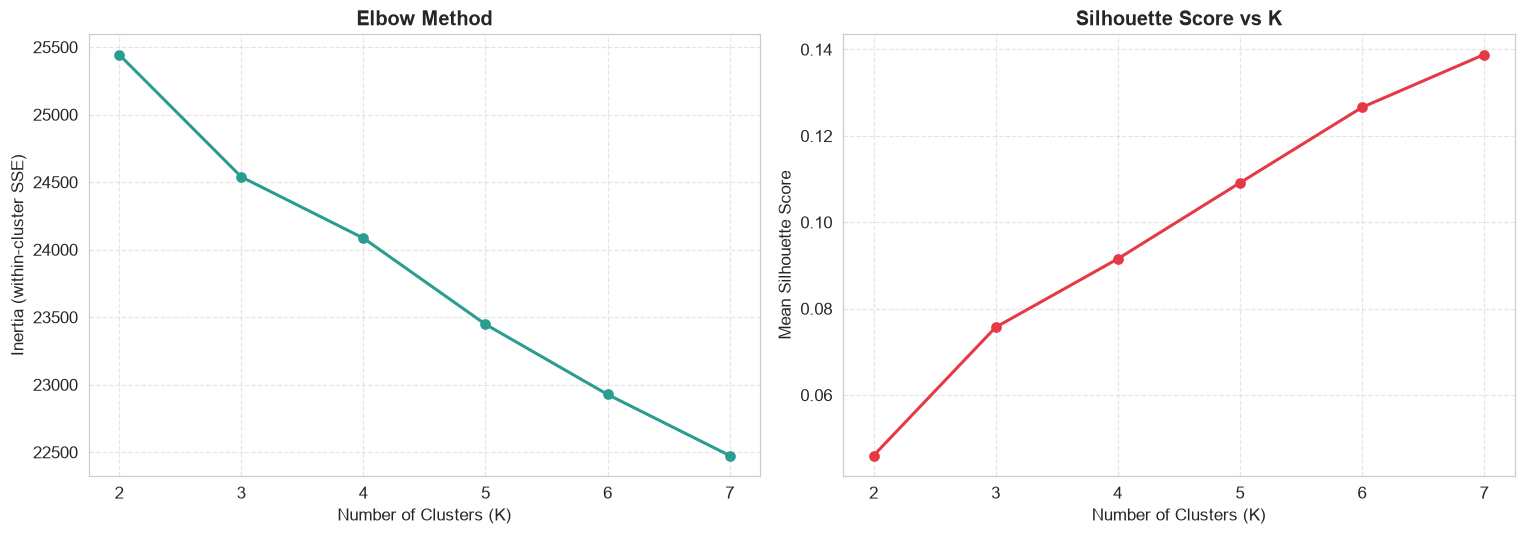

In [25]:
k_range = range(2, 8)
inertias = []
sil_scores = []

# Subsample for the silhouette score if the dataset is large (it's O(n^2))
rng = np.random.default_rng(42)
sample_idx = rng.choice(X.shape[0], size=min(5000, X.shape[0]), replace=False)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X[sample_idx], km.labels_[sample_idx]))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(k_range), inertias, 'o-', color='#2A9D8F', linewidth=2)
axes[0].set_title('Elbow Method', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (within-cluster SSE)')
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].plot(list(k_range), sil_scores, 'o-', color='#E63946', linewidth=2)
axes[1].set_title('Silhouette Score vs K', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Mean Silhouette Score')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


In [26]:
n_clusters = 4

kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X)

print(f"Silhouette score (K={n_clusters}): {silhouette_score(X[sample_idx], cluster_labels[sample_idx]):.3f}")


Silhouette score (K=4): 0.092


In [27]:
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X)
centers_pca_2d = pca_2d.transform(kmeans.cluster_centers_)
var_2d = pca_2d.explained_variance_ratio_

pca_3d = PCA(n_components=3, random_state=42)
X_pca_3d = pca_3d.fit_transform(X)
centers_pca_3d = pca_3d.transform(kmeans.cluster_centers_)
var_3d = pca_3d.explained_variance_ratio_

print(f"2D PCA explained variance: {var_2d.sum()*100:.1f}%  {var_2d*100}")
print(f"3D PCA explained variance: {var_3d.sum()*100:.1f}%  {var_3d*100}")

colors = ['#E63946', '#2A9D8F', '#F4A261', '#457B9D', '#9B5DE5', '#00BBF9'][:n_clusters]


2D PCA explained variance: 8.7%  [4.6263847 4.079167 ]
3D PCA explained variance: 11.2%  [4.626013  4.0791855 2.5176022]


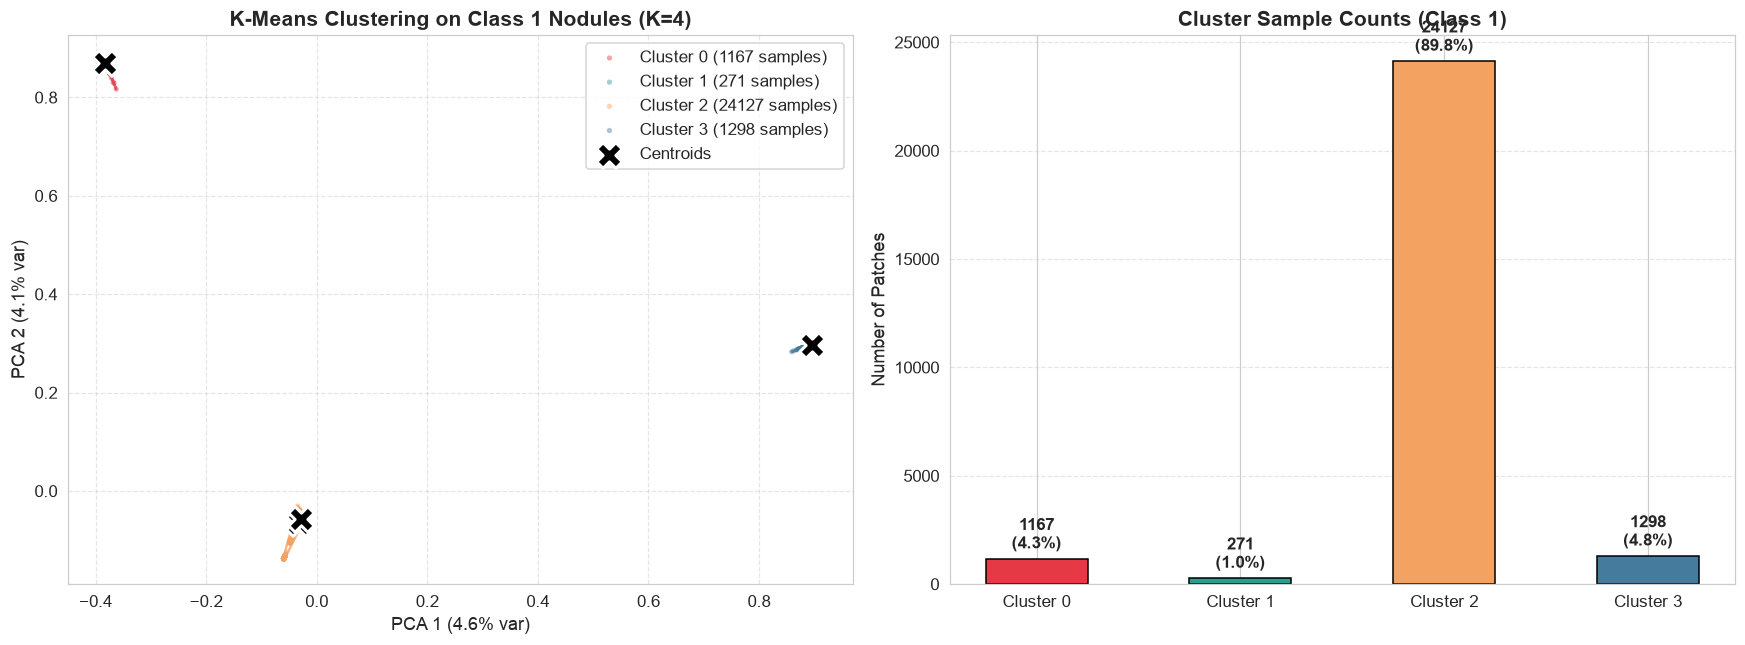

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for c in range(n_clusters):
    mask_c = (cluster_labels == c)
    pts = X_pca_2d[mask_c]

    axes[0].scatter(pts[:, 0], pts[:, 1], c=colors[c],
                     label=f'Cluster {c} ({mask_c.sum()} samples)',
                     alpha=0.45, s=12, edgecolors='none')

    # Convex hull outline (only if enough points)
    if pts.shape[0] >= 3:
        hull = ConvexHull(pts)
        hull_pts = np.append(hull.vertices, hull.vertices[0])
        axes[0].plot(pts[hull_pts, 0], pts[hull_pts, 1], color=colors[c], linewidth=1.5, alpha=0.8)

axes[0].scatter(centers_pca_2d[:, 0], centers_pca_2d[:, 1],
                c='black', marker='X', s=280, linewidths=2, edgecolor='white', label='Centroids', zorder=5)
axes[0].set_title(f'K-Means Clustering on Class {TARGET_CLASS} Nodules (K={n_clusters})', fontsize=14, fontweight='bold')
axes[0].set_xlabel(f'PCA 1 ({var_2d[0]*100:.1f}% var)', fontsize=12)
axes[0].set_ylabel(f'PCA 2 ({var_2d[1]*100:.1f}% var)', fontsize=12)
axes[0].legend(loc='best', frameon=True)
axes[0].grid(True, linestyle='--', alpha=0.5)

cluster_counts = pd.Series(cluster_labels).value_counts().sort_index()
bars = axes[1].bar([f'Cluster {i}' for i in cluster_counts.index], cluster_counts.values,
                    color=colors, edgecolor='black', width=0.5)
axes[1].set_title(f'Cluster Sample Counts (Class {TARGET_CLASS})', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Patches', fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.5, axis='y')
for bar, v in zip(bars, cluster_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + max(cluster_counts.values)*0.02,
                 f'{v}\n({v/len(cluster_labels)*100:.1f}%)', ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()


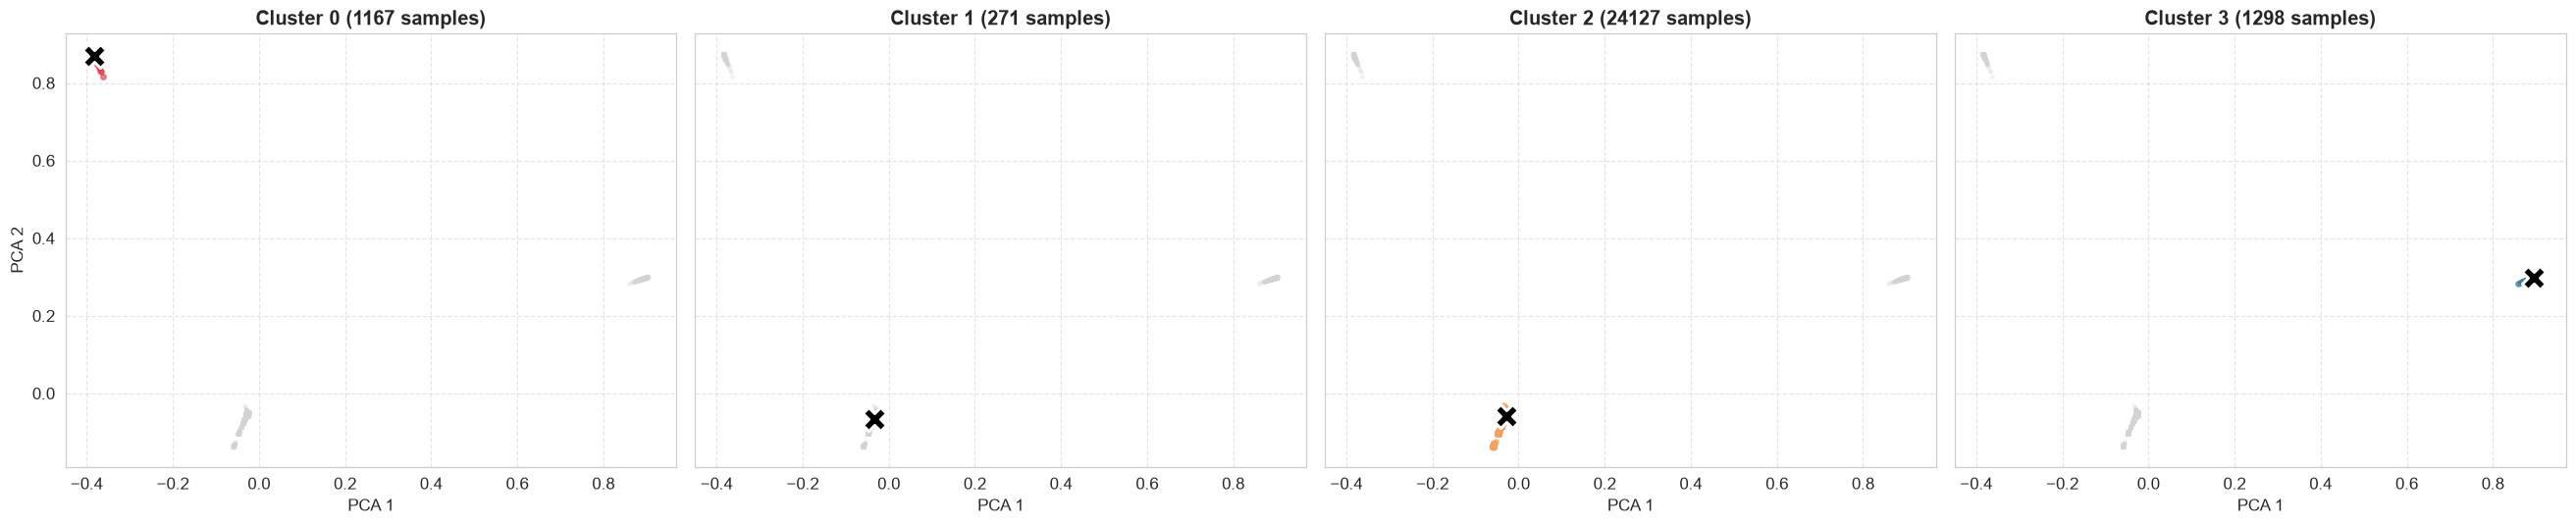

In [29]:
fig, axes = plt.subplots(1, n_clusters, figsize=(6 * n_clusters, 5), sharex=True, sharey=True)
if n_clusters == 1:
    axes = [axes]

for c in range(n_clusters):
    axes[c].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c='lightgrey', alpha=0.2, s=5)

    mask_c = (cluster_labels == c)
    axes[c].scatter(X_pca_2d[mask_c, 0], X_pca_2d[mask_c, 1], c=colors[c], alpha=0.6, s=12, label=f'Cluster {c}')
    axes[c].scatter(centers_pca_2d[c, 0], centers_pca_2d[c, 1], c='black', marker='X',
                     s=250, linewidths=2, edgecolor='white')
    axes[c].set_title(f'Cluster {c} ({mask_c.sum()} samples)', fontsize=13, fontweight='bold')
    axes[c].set_xlabel('PCA 1')
    if c == 0:
        axes[c].set_ylabel('PCA 2')
    axes[c].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


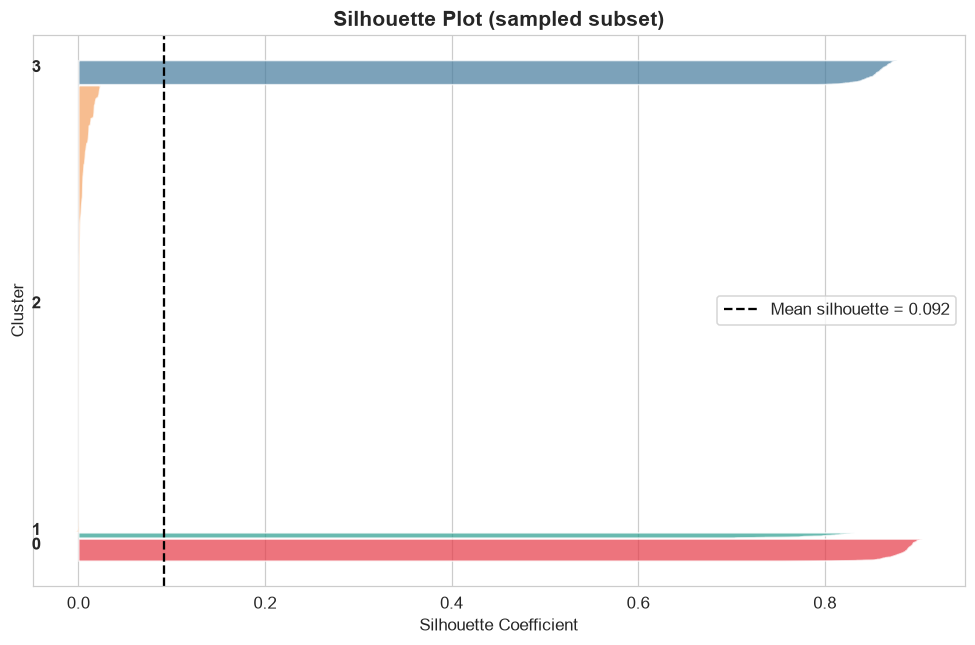

In [30]:
sil_vals = silhouette_samples(X[sample_idx], cluster_labels[sample_idx])
sil_avg = sil_vals.mean()

fig, ax = plt.subplots(figsize=(9, 6))
y_lower = 10
for c in range(n_clusters):
    c_vals = np.sort(sil_vals[cluster_labels[sample_idx] == c])
    y_upper = y_lower + len(c_vals)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, c_vals, facecolor=colors[c], alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * len(c_vals), f'{c}', fontweight='bold')
    y_lower = y_upper + 10

ax.axvline(x=sil_avg, color='black', linestyle='--', label=f'Mean silhouette = {sil_avg:.3f}')
ax.set_title('Silhouette Plot (sampled subset)', fontsize=14, fontweight='bold')
ax.set_xlabel('Silhouette Coefficient')
ax.set_ylabel('Cluster')
ax.set_yticks([])
ax.legend(loc='best')
plt.tight_layout()
plt.show()


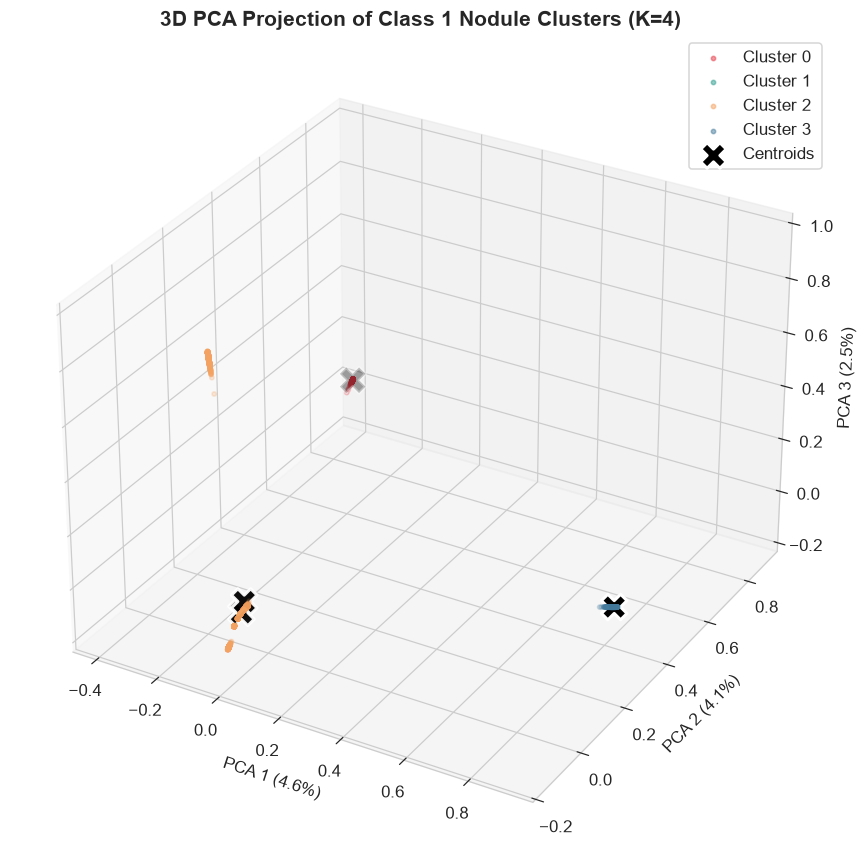

In [31]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

for c in range(n_clusters):
    mask_c = (cluster_labels == c)
    ax.scatter(X_pca_3d[mask_c, 0], X_pca_3d[mask_c, 1], X_pca_3d[mask_c, 2],
               c=colors[c], label=f'Cluster {c}', alpha=0.5, s=8)

ax.scatter(centers_pca_3d[:, 0], centers_pca_3d[:, 1], centers_pca_3d[:, 2],
           c='black', marker='X', s=280, linewidths=2, edgecolor='white', label='Centroids')

ax.set_title(f'3D PCA Projection of Class {TARGET_CLASS} Nodule Clusters (K={n_clusters})', fontsize=14, fontweight='bold')
ax.set_xlabel(f'PCA 1 ({var_3d[0]*100:.1f}%)')
ax.set_ylabel(f'PCA 2 ({var_3d[1]*100:.1f}%)')
ax.set_zlabel(f'PCA 3 ({var_3d[2]*100:.1f}%)')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()


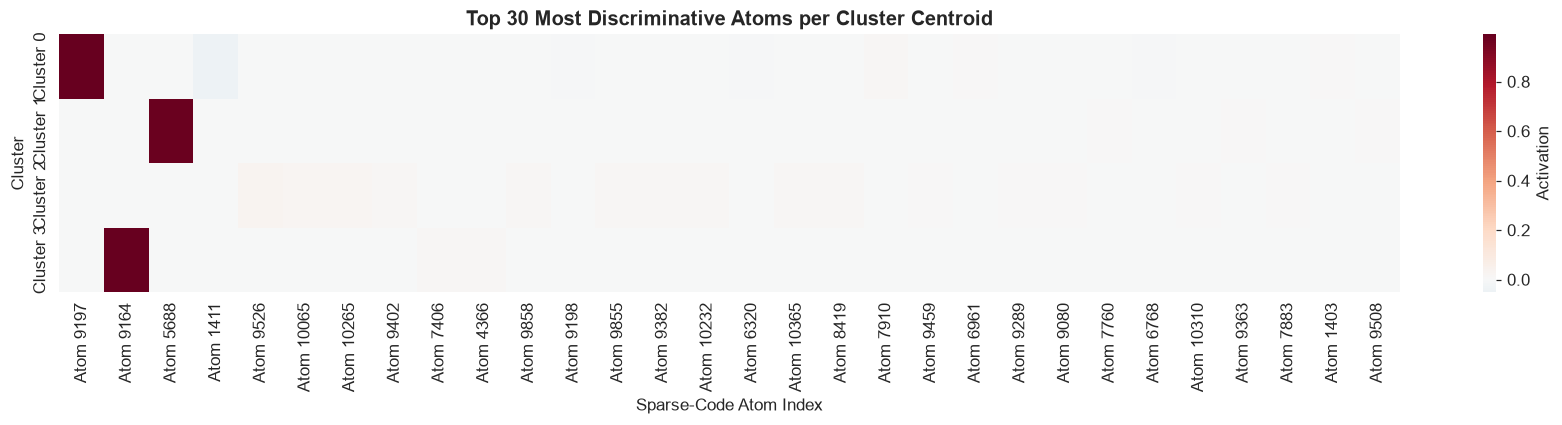

In [32]:
top_n_atoms = 30

# Rank atoms by variance across cluster centroids (most discriminative atoms first)
centroid_variance = kmeans.cluster_centers_.var(axis=0)
top_atoms = np.argsort(centroid_variance)[::-1][:top_n_atoms]

centroid_df = pd.DataFrame(
    kmeans.cluster_centers_[:, top_atoms],
    index=[f'Cluster {c}' for c in range(n_clusters)],
    columns=[f'Atom {i}' for i in top_atoms]
)

plt.figure(figsize=(16, 4))
sns.heatmap(centroid_df, cmap='RdBu_r', center=0, annot=False, cbar_kws={'label': 'Activation'})
plt.title(f'Top {top_n_atoms} Most Discriminative Atoms per Cluster Centroid', fontsize=13, fontweight='bold')
plt.xlabel('Sparse-Code Atom Index')
plt.ylabel('Cluster')
plt.tight_layout()
plt.show()


# GGO frozen


In [33]:
FILE_PATH = '/Users/pasanthilakshana/Desktop/Research/folder/sparse_codes/train_sparse_codes_frozen.npz'
TARGET_CLASS = 1  # 2 = Class 2D nodules , 1 = 2c

data = np.load(FILE_PATH)
Gamma = data['Gamma']     # Shape: (n_atoms, n_samples)
labels = data['labels']   # Shape: (n_samples,)

mask = (labels == TARGET_CLASS)
X_raw = Gamma[:, mask].T  # Shape: (n_class_samples, n_atoms)

print(f"Gamma shape        : {Gamma.shape}")
print(f"Samples in class {TARGET_CLASS}: {X_raw.shape[0]}")
print(f"Sparse-code dim     : {X_raw.shape[1]}")


Gamma shape        : (12096, 118705)
Samples in class 1: 27196
Sparse-code dim     : 12096


In [34]:
normalizer = Normalizer(norm='l2')
X = normalizer.fit_transform(X_raw)


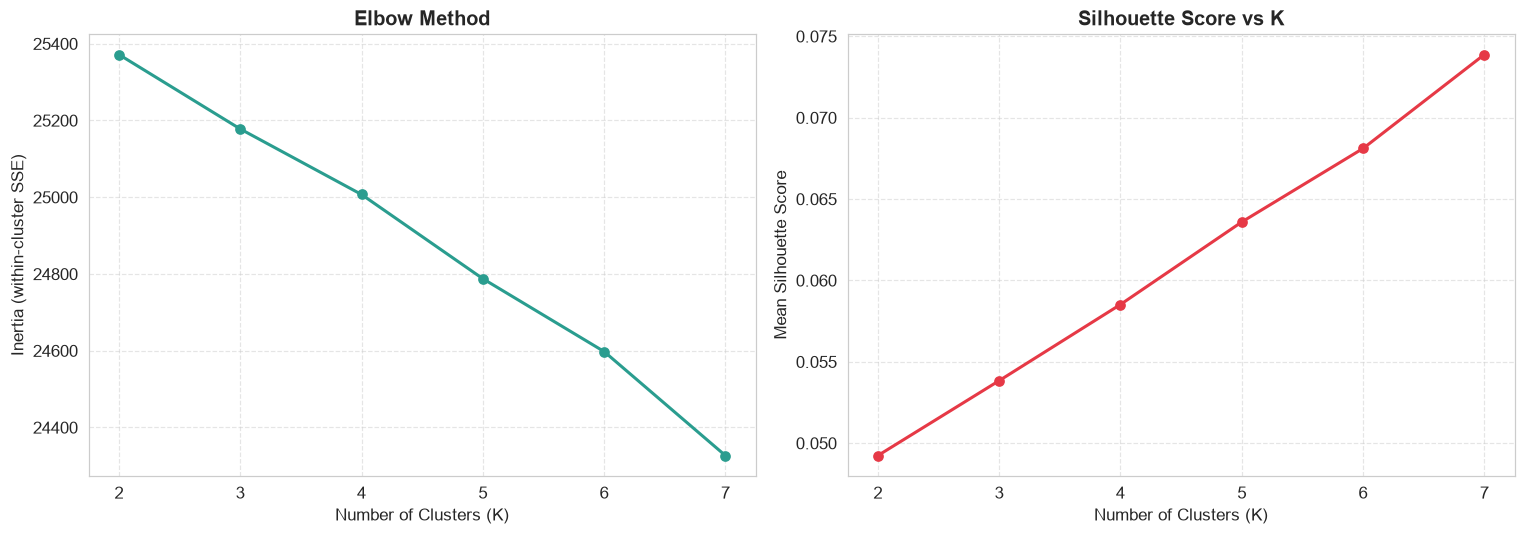

In [35]:
k_range = range(2, 8)
inertias = []
sil_scores = []

# Subsample for the silhouette score if the dataset is large (it's O(n^2))
rng = np.random.default_rng(42)
sample_idx = rng.choice(X.shape[0], size=min(5000, X.shape[0]), replace=False)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X[sample_idx], km.labels_[sample_idx]))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(k_range), inertias, 'o-', color='#2A9D8F', linewidth=2)
axes[0].set_title('Elbow Method', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (within-cluster SSE)')
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].plot(list(k_range), sil_scores, 'o-', color='#E63946', linewidth=2)
axes[1].set_title('Silhouette Score vs K', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Mean Silhouette Score')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


In [41]:
n_clusters = 4

kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X)

print(f"Silhouette score (K={n_clusters}): {silhouette_score(X[sample_idx], cluster_labels[sample_idx]):.3f}")


Silhouette score (K=4): 0.059


In [42]:
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X)
centers_pca_2d = pca_2d.transform(kmeans.cluster_centers_)
var_2d = pca_2d.explained_variance_ratio_

pca_3d = PCA(n_components=3, random_state=42)
X_pca_3d = pca_3d.fit_transform(X)
centers_pca_3d = pca_3d.transform(kmeans.cluster_centers_)
var_3d = pca_3d.explained_variance_ratio_

print(f"2D PCA explained variance: {var_2d.sum()*100:.1f}%  {var_2d*100}")
print(f"3D PCA explained variance: {var_3d.sum()*100:.1f}%  {var_3d*100}")

colors = ['#E63946', '#2A9D8F', '#F4A261', '#457B9D', '#9B5DE5', '#00BBF9'][:n_clusters]


2D PCA explained variance: 7.0%  [6.0021477  0.95018864]
3D PCA explained variance: 7.8%  [6.0021477  0.95435196 0.85541254]


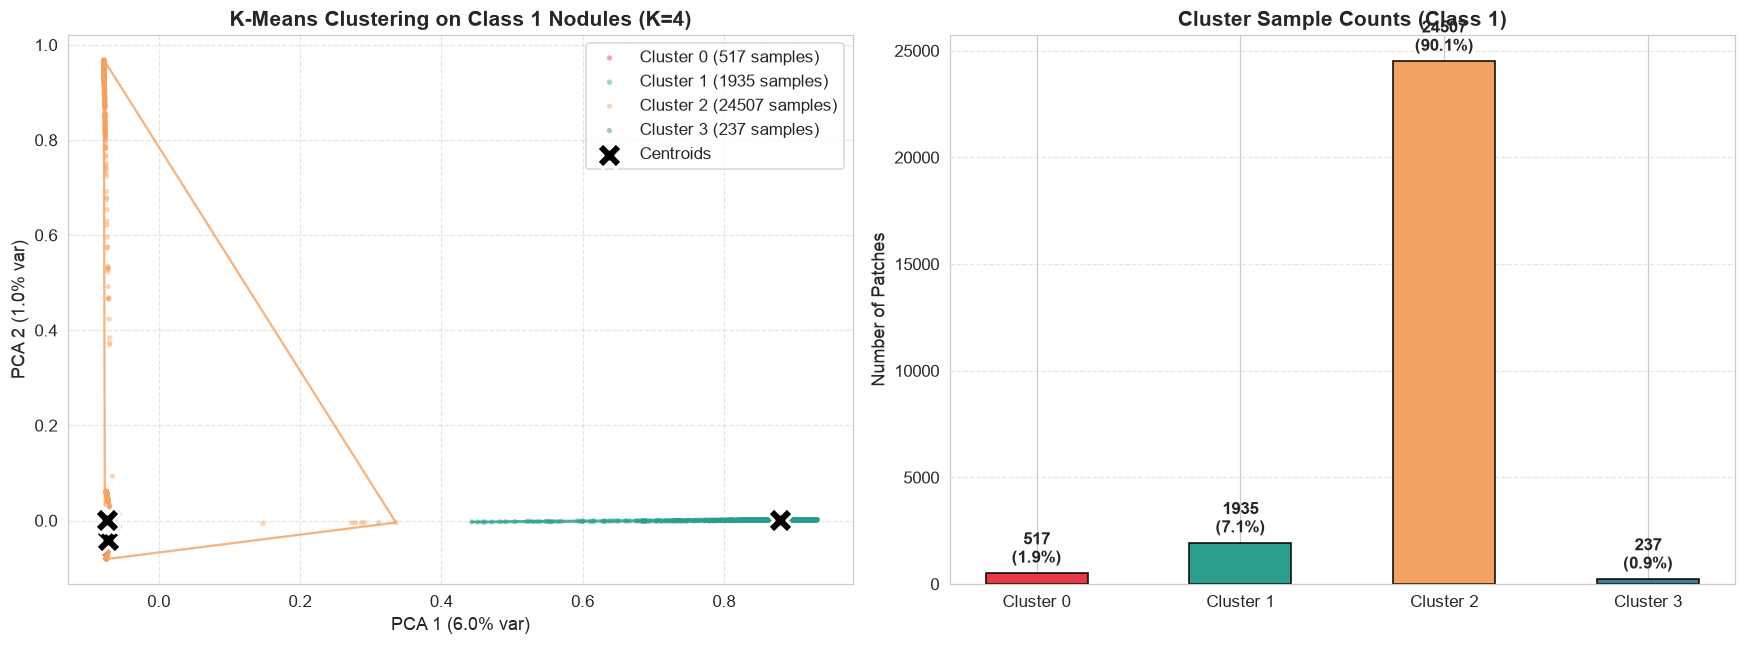

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for c in range(n_clusters):
    mask_c = (cluster_labels == c)
    pts = X_pca_2d[mask_c]

    axes[0].scatter(pts[:, 0], pts[:, 1], c=colors[c],
                     label=f'Cluster {c} ({mask_c.sum()} samples)',
                     alpha=0.45, s=12, edgecolors='none')

    # Convex hull outline (only if enough points)
    if pts.shape[0] >= 3:
        hull = ConvexHull(pts)
        hull_pts = np.append(hull.vertices, hull.vertices[0])
        axes[0].plot(pts[hull_pts, 0], pts[hull_pts, 1], color=colors[c], linewidth=1.5, alpha=0.8)

axes[0].scatter(centers_pca_2d[:, 0], centers_pca_2d[:, 1],
                c='black', marker='X', s=280, linewidths=2, edgecolor='white', label='Centroids', zorder=5)
axes[0].set_title(f'K-Means Clustering on Class {TARGET_CLASS} Nodules (K={n_clusters})', fontsize=14, fontweight='bold')
axes[0].set_xlabel(f'PCA 1 ({var_2d[0]*100:.1f}% var)', fontsize=12)
axes[0].set_ylabel(f'PCA 2 ({var_2d[1]*100:.1f}% var)', fontsize=12)
axes[0].legend(loc='best', frameon=True)
axes[0].grid(True, linestyle='--', alpha=0.5)

cluster_counts = pd.Series(cluster_labels).value_counts().sort_index()
bars = axes[1].bar([f'Cluster {i}' for i in cluster_counts.index], cluster_counts.values,
                    color=colors, edgecolor='black', width=0.5)
axes[1].set_title(f'Cluster Sample Counts (Class {TARGET_CLASS})', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Patches', fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.5, axis='y')
for bar, v in zip(bars, cluster_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + max(cluster_counts.values)*0.02,
                 f'{v}\n({v/len(cluster_labels)*100:.1f}%)', ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()


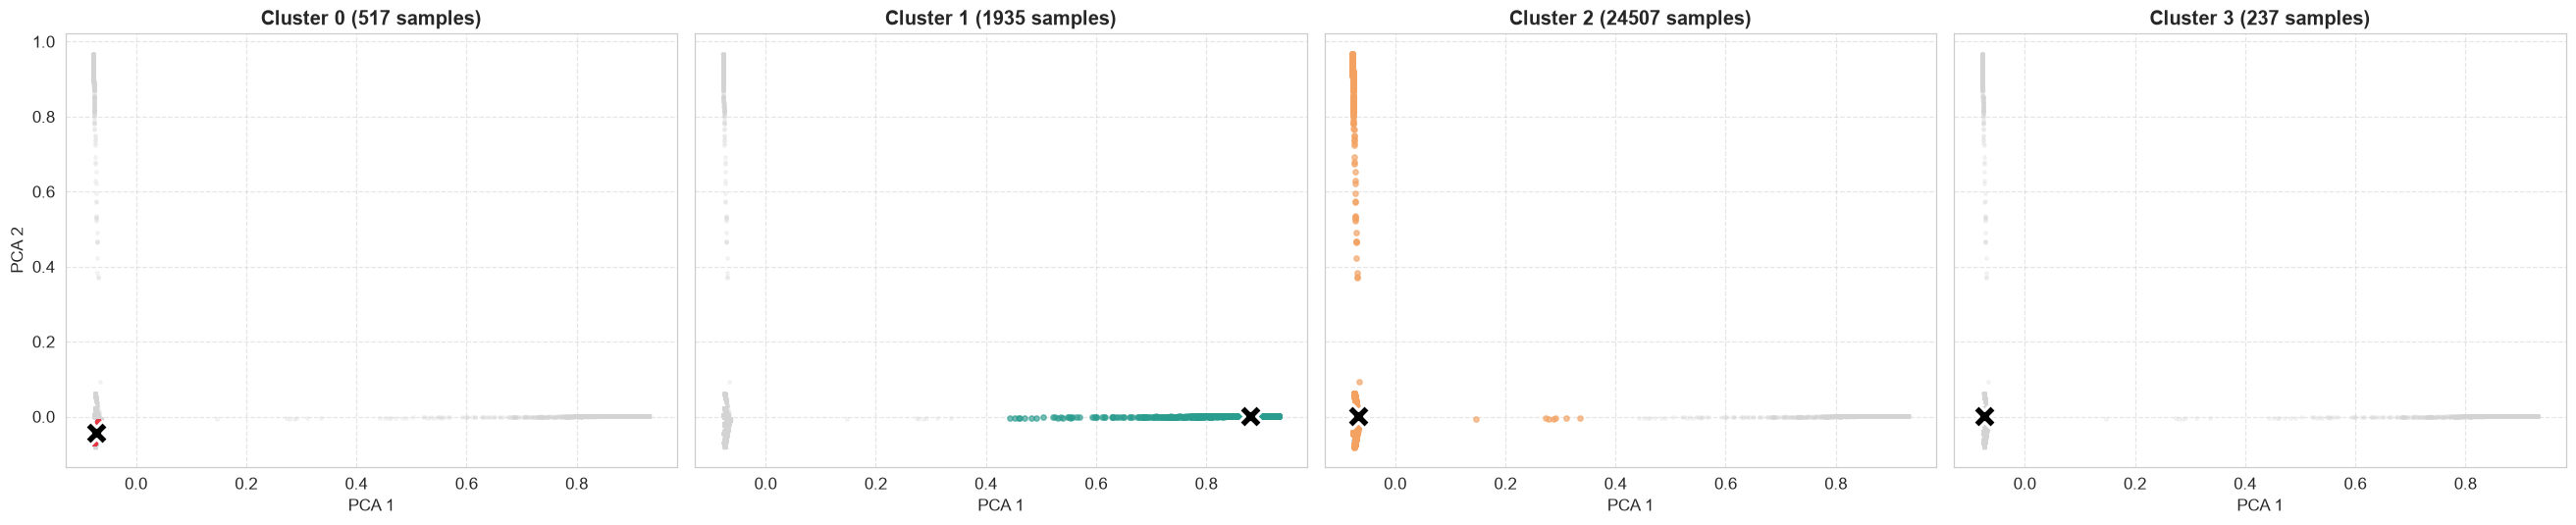

In [44]:
fig, axes = plt.subplots(1, n_clusters, figsize=(6 * n_clusters, 5), sharex=True, sharey=True)
if n_clusters == 1:
    axes = [axes]

for c in range(n_clusters):
    axes[c].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c='lightgrey', alpha=0.2, s=5)

    mask_c = (cluster_labels == c)
    axes[c].scatter(X_pca_2d[mask_c, 0], X_pca_2d[mask_c, 1], c=colors[c], alpha=0.6, s=12, label=f'Cluster {c}')
    axes[c].scatter(centers_pca_2d[c, 0], centers_pca_2d[c, 1], c='black', marker='X',
                     s=250, linewidths=2, edgecolor='white')
    axes[c].set_title(f'Cluster {c} ({mask_c.sum()} samples)', fontsize=13, fontweight='bold')
    axes[c].set_xlabel('PCA 1')
    if c == 0:
        axes[c].set_ylabel('PCA 2')
    axes[c].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


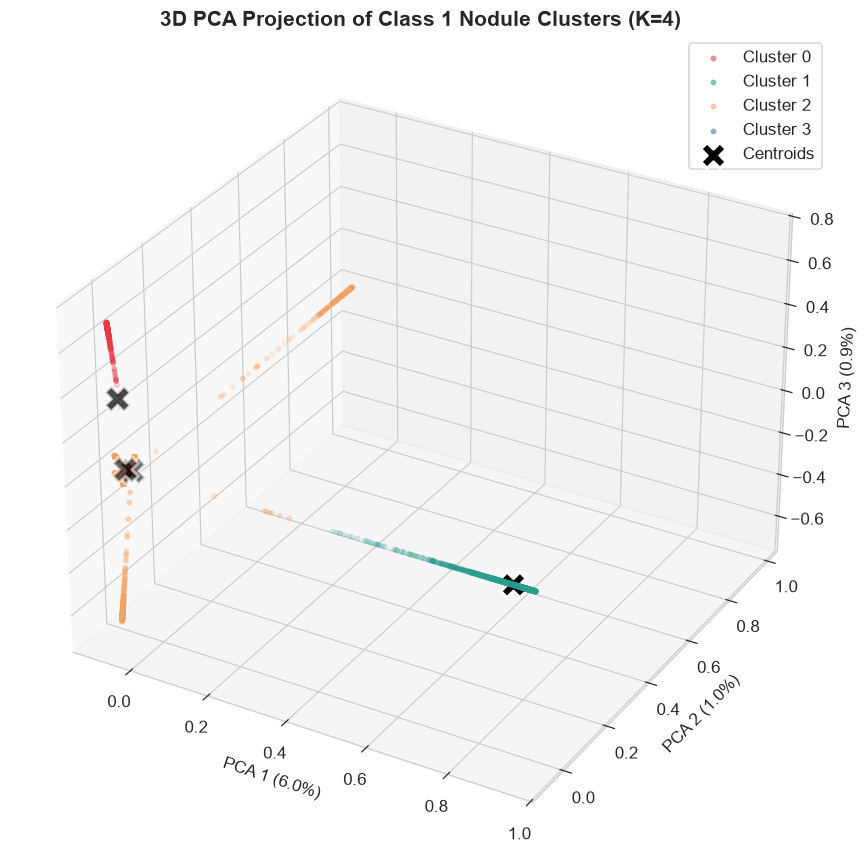

In [45]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

for c in range(n_clusters):
    mask_c = (cluster_labels == c)
    ax.scatter(X_pca_3d[mask_c, 0], X_pca_3d[mask_c, 1], X_pca_3d[mask_c, 2],
               c=colors[c], label=f'Cluster {c}', alpha=0.5, s=8)

ax.scatter(centers_pca_3d[:, 0], centers_pca_3d[:, 1], centers_pca_3d[:, 2],
           c='black', marker='X', s=280, linewidths=2, edgecolor='white', label='Centroids')

ax.set_title(f'3D PCA Projection of Class {TARGET_CLASS} Nodule Clusters (K={n_clusters})', fontsize=14, fontweight='bold')
ax.set_xlabel(f'PCA 1 ({var_3d[0]*100:.1f}%)')
ax.set_ylabel(f'PCA 2 ({var_3d[1]*100:.1f}%)')
ax.set_zlabel(f'PCA 3 ({var_3d[2]*100:.1f}%)')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()
